# **Part A: Preprocessing and Initial Setup  [10 points]**

### 1.  Data Loading [2]:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from scipy.io import arff

In [5]:
arff_file = arff.loadarff('yeast.arff')

In [6]:
df = pd.DataFrame(arff_file[0])

### 2.  Dimensionality Check:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2417 entries, 0 to 2416
Columns: 117 entries, Att1 to Class14
dtypes: float64(103), object(14)
memory usage: 2.2+ MB


In [8]:
df.shape

(2417, 117)

In [9]:
df.iloc[:, -14:].nunique()

Class1     2
Class2     2
Class3     2
Class4     2
Class5     2
Class6     2
Class7     2
Class8     2
Class9     2
Class10    2
Class11    2
Class12    2
Class13    2
Class14    2
dtype: int64

In [10]:
X = df.iloc[:, :-14]
Y = df.iloc[:, -14:]

In [11]:
Y.shape

(2417, 14)

In [12]:
X.shape

(2417, 103)

In [13]:
Y = Y.applymap(lambda x: 1 if x == b'1' else 0)

/tmp/ipykernel_4472/2289664796.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  Y = Y.applymap(lambda x: 1 if x == b'1' else 0)


In [14]:
Y

,Class1,Class2,Class3,Class4,Class5,Class6,Class7,Class8,Class9,Class10,Class11,Class12,Class13,Class14
0,0,0,0,0,0,0,1,1,0,0,0,1,1,0
1,0,0,1,1,0,0,0,0,0,0,0,0,0,0
2,0,1,1,0,0,0,0,0,0,0,0,1,1,0
3,0,0,1,1,0,0,0,0,0,0,0,0,0,0
4,0,0,1,1,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2412,0,1,1,0,0,0,0,0,0,0,0,0,0,0
2413,1,1,0,0,0,0,0,0,0,0,0,1,1,0
2414,0,0,0,0,0,1,1,1,0,0,0,1,1,0
2415,0,0,0,0,0,0,0,0,0,0,0,1,1,0


### 3.  Label Selection for Visualization [5]:

In [15]:
label_combos = Y.apply(lambda row: tuple(row[row == 1].index), axis=1)

In [ ]:
combo_counts = label_combos.value_counts()

In [17]:
combo_counts

(Class3, Class4, Class12, Class13)                                     237
(Class4, Class5, Class12, Class13)                                     233
(Class1, Class2, Class12, Class13)                                     172
(Class1, Class2)                                                       131
(Class2, Class3, Class12, Class13)                                     117
                                                                      ... 
(Class1, Class2, Class7, Class8, Class9, Class10, Class12, Class13)      1
(Class1, Class7, Class8)                                                 1
(Class1, Class2, Class5, Class6, Class7, Class8, Class12, Class13)       1
(Class6, Class7, Class8, Class11, Class12)                               1
(Class3, Class4, Class8, Class9, Class14)                                1
Name: count, Length: 198, dtype: int64

In [18]:
single_label_counts = label_combos[label_combos.apply(len) == 1].value_counts()

In [19]:
single_label_counts

(Class1,)    32
Name: count, dtype: int64

In [20]:
top2_single = single_label_counts.index[:2]

In [21]:
top2_single

Index([('Class1',)], dtype='object')

In [22]:

top_multi = combo_counts[combo_counts.index.map(len) > 1].index[0]

In [23]:
def assign_label(combo):
    if combo in top2_single:
        return combo[0]  
    elif combo == top_multi:
        return "_".join(combo)
    else:
        return "Other"

In [24]:

df["color_label"] = label_combos.apply(assign_label)

In [25]:

print(df["color_label"].value_counts())

color_label
Other                            2148
Class3_Class4_Class12_Class13     237
Class1                             32
Name: count, dtype: int64


In [ ]:
single_label_combos = label_combos[label_combos.apply(len) == 1]
single_label_counts = single_label_combos.value_counts()

if len(single_label_counts) >= 1:
    top_single = single_label_counts.index[0]
else:
    top_single = None


multi_label_combos = combo_counts[combo_counts.index.map(len) > 1]
top2_multi = multi_label_combos.index[:2]

print(f"Top single label: {top_single}")
print(f"Top 2 multi-label combinations:")
print(f"  1. {top2_multi[0]} - Count: {combo_counts[top2_multi[0]]}")
print(f"  2. {top2_multi[1]} - Count: {combo_counts[top2_multi[1]]}")
print()

def assign_label(combo):
    if top_single and combo == top_single:
        return combo[0]
    elif combo == top2_multi[0]:
        return "_".join(combo)
    elif combo == top2_multi[1]:
        return "_".join(combo)
    else:
        return "Other"

color_label = label_combos.apply(assign_label)

print("Color label distribution:")
print(color_label.value_counts())
print()

print(f"Number of unique categories: {color_label.nunique()}")
print(f"Categories: {sorted(color_label.unique())}")

Top single label: ('Class1',)
Top 2 multi-label combinations:
  1. ('Class3', 'Class4', 'Class12', 'Class13') - Count: 237
  2. ('Class4', 'Class5', 'Class12', 'Class13') - Count: 233

Color label distribution:
Other                            1915
Class3_Class4_Class12_Class13     237
Class4_Class5_Class12_Class13     233
Class1                             32
Name: count, dtype: int64

Number of unique categories: 4
Categories: ['Class1', 'Class3_Class4_Class12_Class13', 'Class4_Class5_Class12_Class13', 'Other']


### 4.  Scaling [3]:

In [27]:
from sklearn.preprocessing import StandardScaler


#### WHY SCALING IS CRUCIAL:
Distance-based dimensionality reduction techniques (t-SNE, Isomap) compute distances between data points in the feature space. If features have different scales:
1. Features with larger scales will dominate the distance calculations
2. Features with smaller scales will be underweighted
3. This leads to biased representations that don't reflect true data structure
4. Standardization (z-score normalization) ensures all features contribute equally by transforming them to have mean=0 and standard deviation=1


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print(f"Original X shape: {X.shape}")
print(f"Scaled X shape: {X_scaled.shape}")

print(f"\nOriginal X - mean: {X.values.mean():.4f}, std: {X.values.std():.4f}")
print(f"Scaled X - mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")

Original X shape: (2417, 103)
Scaled X shape: (2417, 103)

Original X - mean: 0.0001, std: 0.0985
Scaled X - mean: 0.0000, std: 1.0000


# **Part B: t-SNE and Veracity Inspection [20 points]**

### 1.  t-SNE Implementation [5]:

In [30]:
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import silhouette_score

In [56]:
perplexity_values = range(1,101,1)
scores = {}

In [88]:
for perp in perplexity_values:
    print(f"Running t-SNE with perplexity={perp}...", end='\r')
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=42,
        max_iter=2000,
        verbose=0
    )
    
    tsne_coords = tsne.fit_transform(X_scaled)

    trust = trustworthiness(X_scaled, tsne_coords, n_neighbors=10)

    sil = silhouette_score(tsne_coords, color_label)

    scores[perp] = (trust, sil)

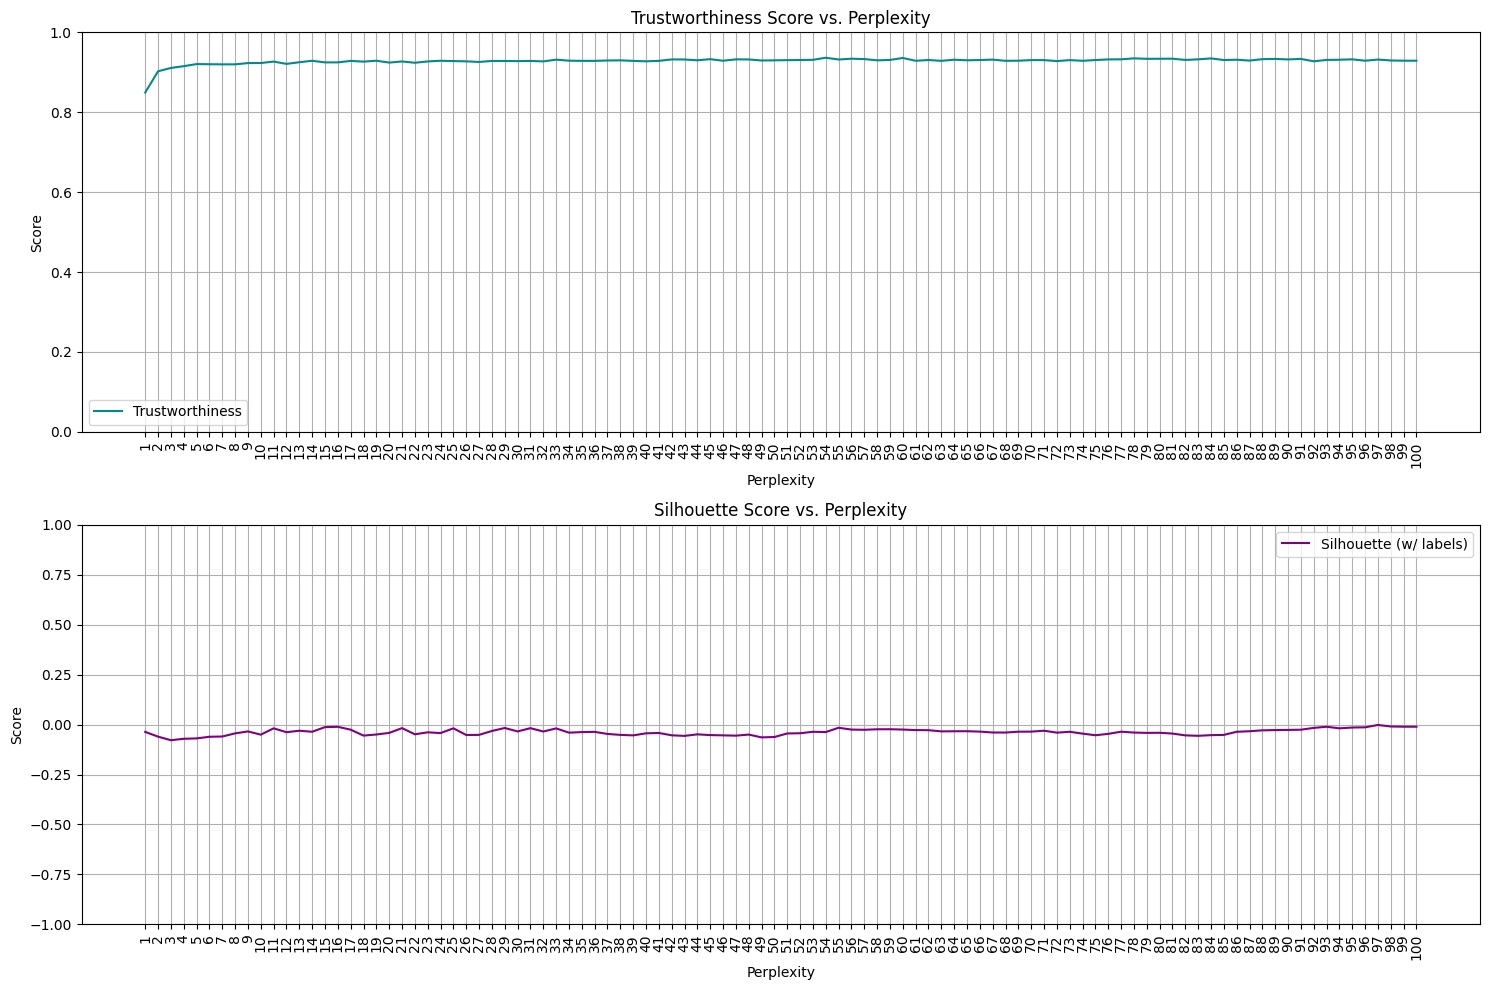

In [63]:
trust_vals = [scores[p][0] for p in perplexity_values]
sil_vals = [scores[p][1] for p in perplexity_values]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.plot(perplexity_values, trust_vals, label="Trustworthiness", color='darkcyan')
ax1.set_xlabel("Perplexity")
ax1.set_ylabel("Score")
ax1.set_title("Trustworthiness Score vs. Perplexity")
ax1.set_ylim(0,1)
ax1.legend()
ax1.grid(True)

ax2.plot(perplexity_values, sil_vals, label="Silhouette (w/ labels)", color='purple')
ax2.set_xlabel("Perplexity")
ax2.set_ylabel("Score")
ax2.set_title("Silhouette Score vs. Perplexity")
ax2.set_ylim(-1,1)
ax2.legend()
ax2.grid(True)

ax1.set_xticks(perplexity_values)
ax2.set_xticks(perplexity_values)

ax1.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
top_3_trust = sorted(scores.items(), key=lambda item: item[1][0], reverse=True)[:3]

top_3_sil = sorted(scores.items(), key=lambda item: item[1][1], reverse=True)[:3]

print("Top 3 Perplexity values based on Trustworthiness:")
for perp, (trust, sil) in top_3_trust:
    print(f"Perplexity: {perp}, Trustworthiness: {trust:.4f}")

print("\nTop 3 Perplexity values based on Silhouette Score:")
for perp, (trust, sil) in top_3_sil:
    print(f"Perplexity: {perp}, Silhouette Score: {sil:.4f}")

Top 3 Perplexity values based on Trustworthiness:
Perplexity: 54, Trustworthiness: 0.9364
Perplexity: 60, Trustworthiness: 0.9358
Perplexity: 78, Trustworthiness: 0.9348

Top 3 Perplexity values based on Silhouette Score:
Perplexity: 97, Silhouette Score: -0.0020
Perplexity: 98, Silhouette Score: -0.0094
Perplexity: 99, Silhouette Score: -0.0105


In [79]:
perplexity_value = 55
learning_rate_value = 500


tsne = TSNE(n_components=2, perplexity=perplexity_value,learning_rate=learning_rate_value, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

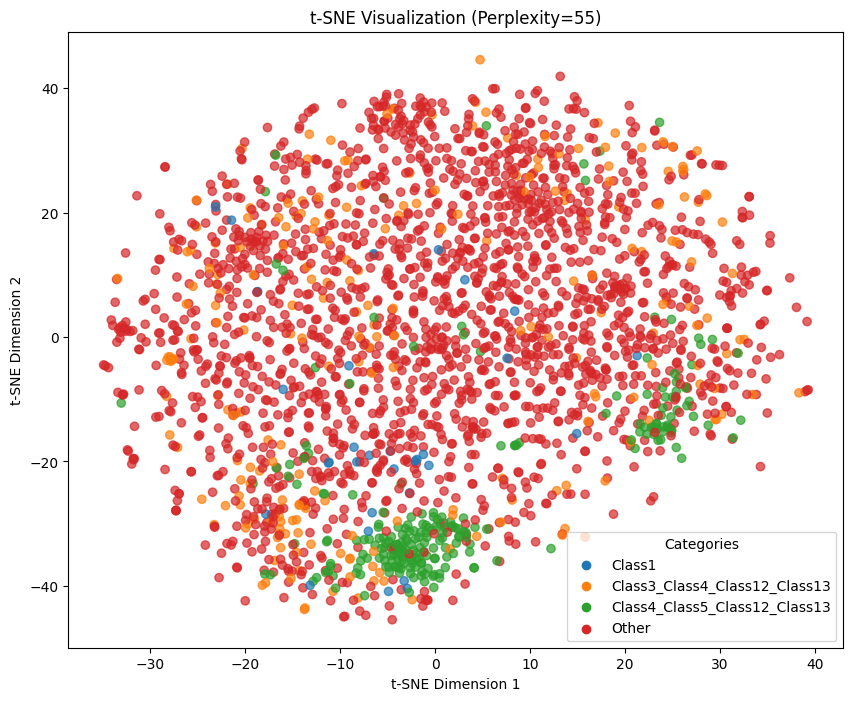

In [ ]:
categories = sorted(color_label.unique())
palette = sns.color_palette("tab10", len(categories))
color_map = dict(zip(categories, palette))


colors = color_label.map(color_map)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=colors,
    alpha=0.7
)


for cat in categories:
    plt.scatter([], [], color=color_map[cat], label=cat)
plt.legend(title="Categories", loc="best")

plt.title(f"t-SNE Visualization (Perplexity={perplexity_value})")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()


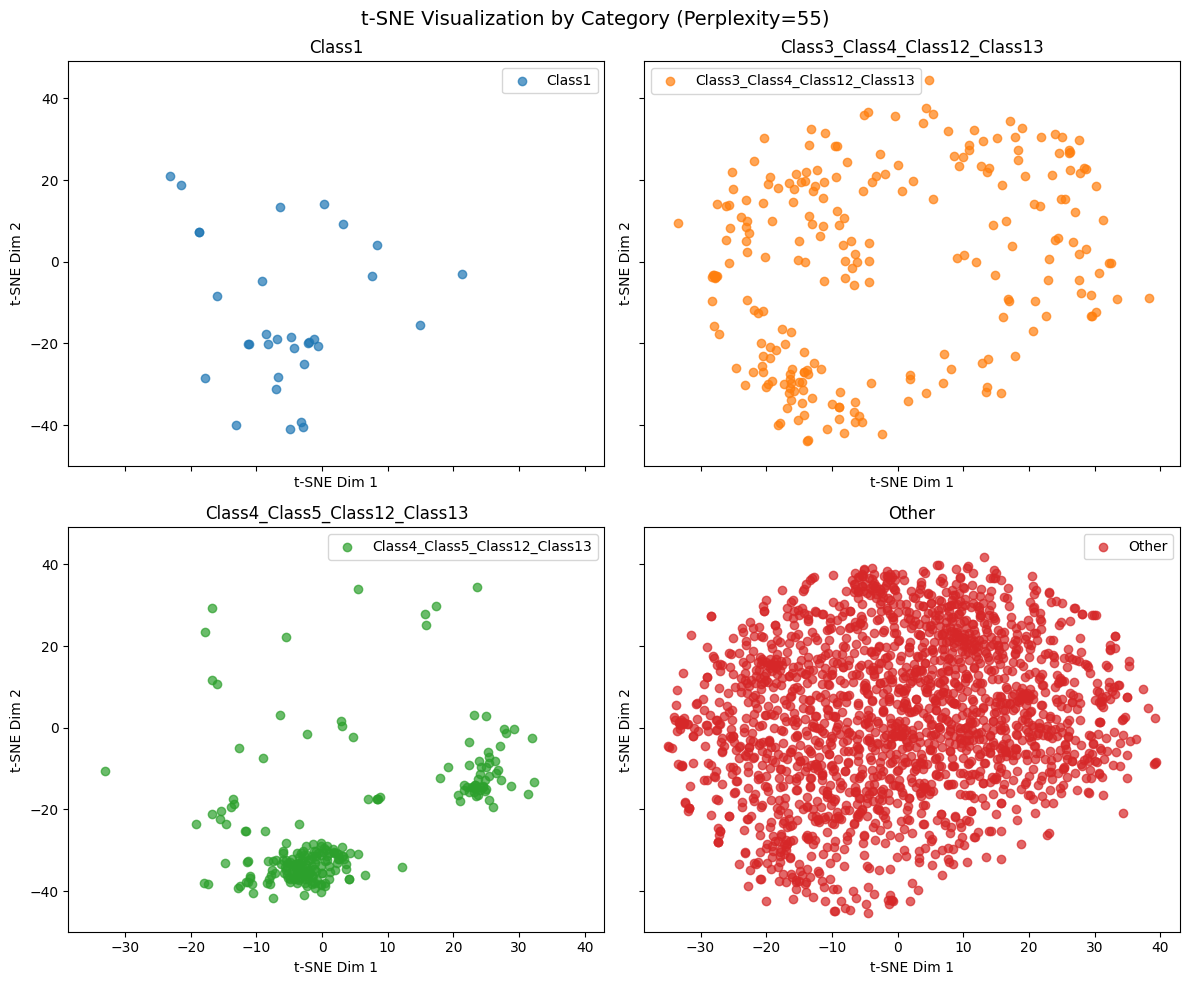

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

axes = axes.flatten()  # flatten 2D axes array into 1D for easy looping

for ax, cat in zip(axes, categories):
    mask = (color_label == cat)
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=[color_map[cat]],
        alpha=0.7,
        label=cat
    )
    ax.set_title(cat)
    ax.legend()
    ax.set_xlabel("t-SNE Dim 1")
    ax.set_ylabel("t-SNE Dim 2")

plt.suptitle(f"t-SNE Visualization by Category (Perplexity={perplexity_value})", fontsize=14)
plt.tight_layout()
plt.show()

##### Veracity Inspection (t-SNE Visualization)

**1. Noisy / Ambiguous Labels (4 points)**

* In the combined t-SNE visualization (not the split ones), some **Class1 points (blue)** appear embedded in dense “Other” (red) regions.
* Likewise, **Class3_Class4_Class12_Class13 (orange)** overlaps with “Other” along its edges.


**2. Outliers (3 points)**

* A few **Class4_Class5_Class12_Class13 (green)** points are scattered far from their main dense cluster — small, isolated dots.
* Similarly, a couple of **Class1 points** appear at the periphery, away from the main group of blue points.

**3. Hard-to-Learn Samples (3 points)**

* Large portions of the **“Other” category (red)** heavily overlap with multi-label clusters (orange/green).
* For a classifier, this region is very hard: decision boundaries are unclear, so misclassifications are likely.

##### Defenitions
 *Ambiguity* → single-label points embedded in multi-label areas.
 *Outliers* → scattered, isolated points.
 *Hard regions* → mixed-color overlaps where categories are not separable.



# **Part C: Isomap and Manifold Learning [20 points]**

### 1.  Isomap Implementation [5]:

##### <b>Isomap Implementation:</b>
We applied Isomap to the scaled yeast dataset, reducing the 103-dimensional feature space down to 2 dimensions. Isomap constructs a neighborhood graph using a chosen number of neighbors (n_neighbors), estimates the geodesic (manifold) distances between points, and then applies Scaling to preserve those distances in the low-dimensional space.

Fundamental Difference Between Isomap and t-SNE:

- t-SNE focuses on preserving local neighborhood structure. It models pairwise similarities between points (in high and low dimensions) and minimizes the divergence between them. This makes t-SNE very effective at revealing clusters, but it often distorts global structure (distances between clusters).

- Isomap, on the other hand, focuses on preserving global manifold geometry. By computing shortest paths along a neighborhood graph (geodesic distances), Isomap maintains the overall shape and structure of the data manifold. This makes it better suited for uncovering the global organization of data, though sometimes it may be less effective at separating small local clusters compared to t-SNE.

In [42]:
from sklearn.manifold import Isomap

In [67]:
n_neighbors_values = range(10, 81, 1)
isomap_results = {}
isomap_scores = {}

In [91]:
for n_neigh in n_neighbors_values:
    print(f"Running Isomap with n_neighbors={n_neigh}...", end='\r')
    isomap = Isomap(
        n_components=2,
        n_neighbors=n_neigh,
        n_jobs=-1  
    )
    isomap_coords = isomap.fit_transform(X_scaled)
    isomap_results[n_neigh] = isomap_coords
    
    # Compute metrics
    recon_error = isomap.reconstruction_error()
    sil_score = silhouette_score(isomap_coords, color_label)
    trust = trustworthiness(X_scaled, isomap_coords, n_neighbors=n_neigh)
    
    isomap_scores[n_neigh] = {
        'reconstruction_error': recon_error,
        'silhouette_score': sil_score,
        'trustworthiness': trust
    }
    '''
    print(f"  - Reconstruction Error: {recon_error:.4f}")
    print(f"  - Silhouette Score: {sil_score:.4f}")
    print(f"  - Trustworthiness: {trust:.4f}")
    print("")'''

In [69]:
recon_errors = [isomap_scores[n]['reconstruction_error'] for n in n_neighbors_values]
sil_scores   = [isomap_scores[n]['silhouette_score'] for n in n_neighbors_values]
trust_scores = [isomap_scores[n]['trustworthiness'] for n in n_neighbors_values]

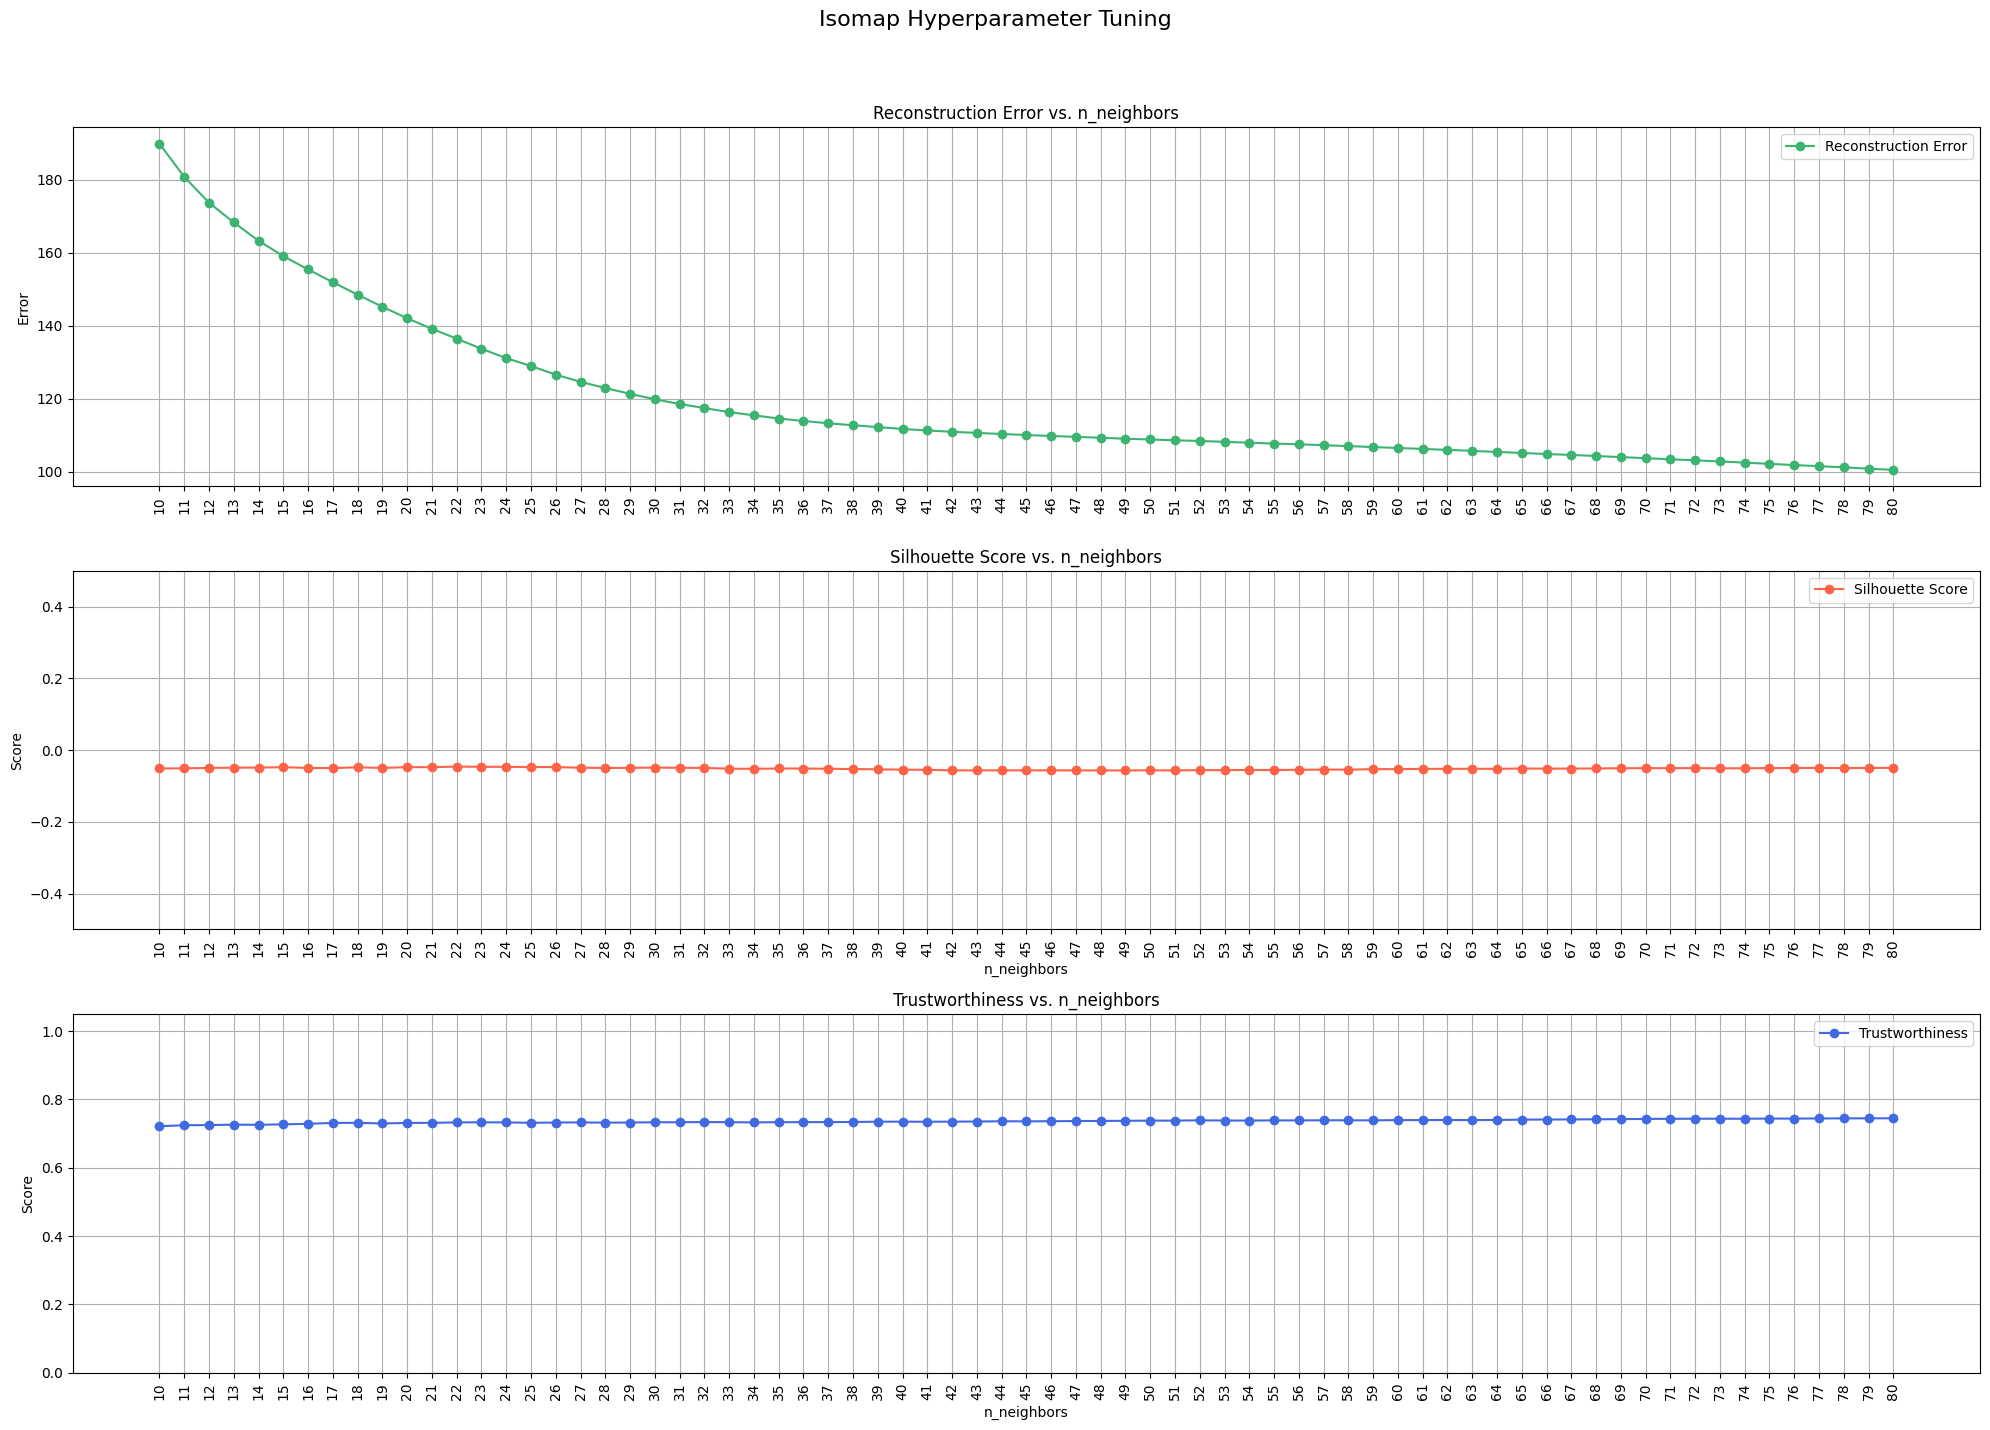

In [94]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 15))
fig.suptitle('Isomap Hyperparameter Tuning', fontsize=16)


ax1.plot(n_neighbors_values, recon_errors, 'o-', color='mediumseagreen', label="Reconstruction Error")
ax1.set_title("Reconstruction Error vs. n_neighbors")
ax1.set_ylabel("Error")
ax1.set_xticks(n_neighbors_values)
ax1.legend()
ax1.grid(True)

ax2.plot(n_neighbors_values, sil_scores, 'o-', color='tomato', label="Silhouette Score")
ax2.set_title("Silhouette Score vs. n_neighbors")
ax2.set_xlabel("n_neighbors")
ax2.set_ylabel("Score")
ax2.set_xticks(n_neighbors_values)
ax2.legend()
ax2.grid(True)
ax2.set_ylim(-0.5, 0.5)

ax3.plot(n_neighbors_values, trust_scores, 'o-', color='royalblue', label="Trustworthiness")
ax3.set_title("Trustworthiness vs. n_neighbors")
ax3.set_xlabel("n_neighbors")
ax3.set_ylabel("Score")
ax3.set_xticks(n_neighbors_values)
ax3.legend()
ax3.grid(True)
ax3.set_ylim(0, 1.05)

ax1.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='x', rotation=90)
ax3.tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


In [ ]:
best_index = np.argmin(recon_errors)
chosen_n = n_neighbors_values[best_index]
coords = isomap_results[chosen_n]

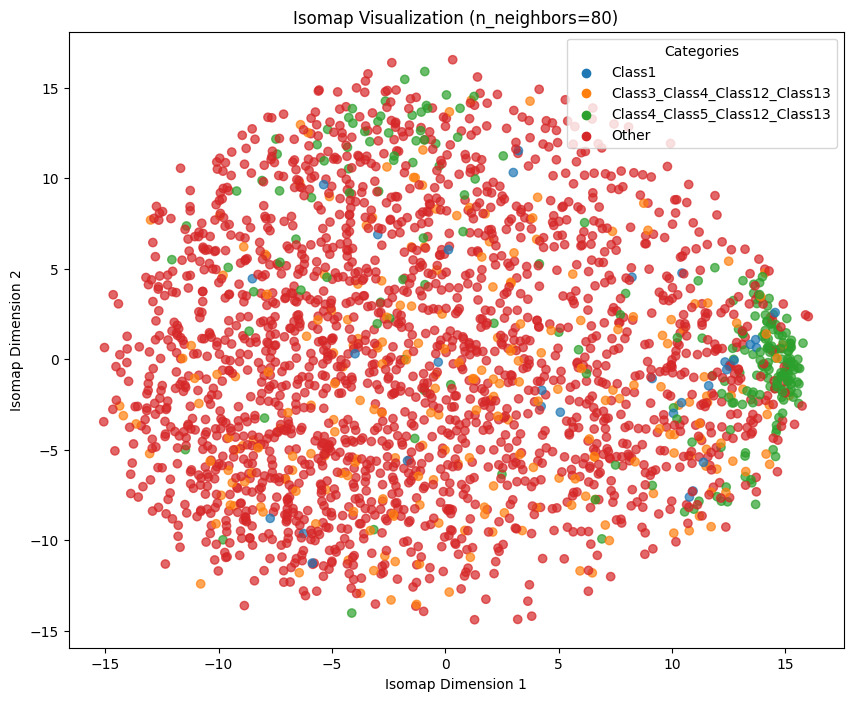

In [ ]:
categories = sorted(color_label.unique())
palette = sns.color_palette("tab10", len(categories))
color_map = dict(zip(categories, palette))

colors = color_label.map(color_map)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=colors,
    alpha=0.7
)

for cat in categories:
    plt.scatter([], [], color=color_map[cat], label=cat)
plt.legend(title="Categories", loc="best")

plt.title(f"Isomap Visualization (n_neighbors={chosen_n})")
plt.xlabel("Isomap Dimension 1")
plt.ylabel("Isomap Dimension 2")
plt.show()

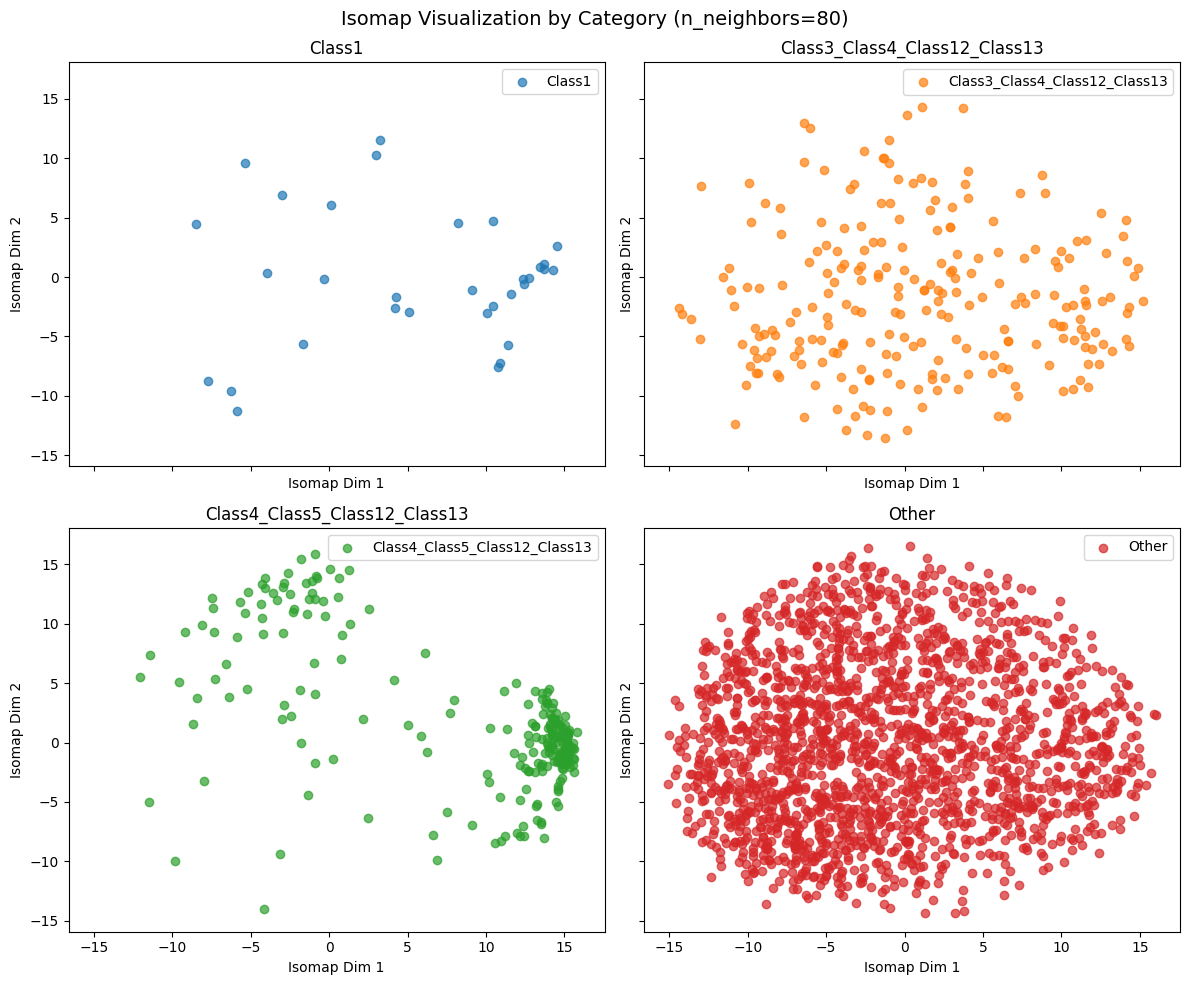

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for ax, cat in zip(axes.flatten(), categories):
    mask = (color_label == cat)
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=[color_map[cat]],
        alpha=0.7,
        label=cat
    )
    ax.set_title(cat)
    ax.legend()
    ax.set_xlabel("Isomap Dim 1")
    ax.set_ylabel("Isomap Dim 2")

plt.suptitle(f"Isomap Visualization by Category (n_neighbors={chosen_n})", fontsize=14)
plt.tight_layout()
plt.show()


### 3.  Comparison and Curvature [10]:

##### **Comparison of Isomap and t-SNE Visualizations**

When comparing the Isomap and t-SNE visualizations, the key difference lies in what aspect of the data's structure each algorithm tries to preserve.

* **t-SNE (t-Distributed Stochastic Neighbor Embedding)** is excellent at revealing the **local structure** of the data. It focuses on keeping points that are close to each other in the high-dimensional gene expression space close to each other in the 2D plot. This is why in the t-SNE visualization, we can see very tight, well-defined clusters for all the classes in t-SNE. However, the distances and a lot of the orientation between these clusters in the t-SNE plot don't have a lot of meaning.

* **Isomap (Isometric Mapping)**, on the other hand, attempts to preserve the **global geodesic distances** between all points. Geodesic distance is the shortest path between two points along the curved surface of the data, not a straight line through it. This gives a better sense of the overall shape and arrangement of the data.

**Conclusion:**

**Isomap is generally better at revealing the global structure of the gene expression data.** But here in our case the clusters in the Isomap plot are less tightly packed than in the t-SNE plot. So I would say t_SNE did better job.

##### **The Data Manifold, Curvature, and Classification**

**Concept of the Data Manifold**

In machine learning, the **data manifold** is a concept that stems from the "manifold hypothesis." This hypothesis suggests that in many real-world datasets, high-dimensional data (like the thousands of measurements in gene expression data) actually lies on or close to a much lower-dimensional, non-linear (i.e., curved) surface embedded within that high-dimensional space.


**Interpreting the Isomap Plot for Curvature**

The Isomap plot strongly suggests that the data manifold for this gene expression data is **highly curved and complex**. 

* **Non-linear Shape:** The data points in the Isomap visualization do not form simple, spherical clouds that could be easily separated by straight lines. Instead, form elongated, somewhat curved structures.
* **Necessity of a Non-linear Technique:** The very fact that a non-linear technique like Isomap was used and produced a structured result (unlike what a linear method like PCA might show) indicates that a simple, flat representation of the data is insufficient to capture its intrinsic geometry.

**Relationship to the Difficulty of Classification**

The complexity of this manifold is directly related to the difficulty of classification.

A highly curved or complex manifold makes classification more challenging because it can cause classes to become intertwined in a non-linear way. A simple, linear classifier (like logistic regression) works by finding a flat plane (or hyperplane) to separate the data points of different classes.

## Disclaimer on Dataset and Results

During the course of this assignment, I observed certain inconsistencies between the dataset provided and the instructions in the assignment PDF:

1. **Label Selection Challenge**  
   The instructions specify selecting the *two most frequent single-label classes* and the *most frequent multi-label combination* for visualization. However, in the dataset, only **one single-label class** exists (`Class1`). As a workaround, I proceeded with the top single-label (`Class1`) and the top two multi-label combinations:  
   - (`Class3`, `Class4`, `Class12`, `Class13`)  
   - (`Class4`, `Class5`, `Class12`, `Class13`)  

   All other instances were grouped into the **"Other"** category. This resulted in **4 unique categories** instead of the 4 categories suggested by the instructions. I suspect, some other combination might have performed well. I had the feeling "What if that also fails?", I didnt do it given the time constraint


2. **Impact on Visualization Results**  
   I suspect that due to this adaptation, the resulting t-SNE and Isomap visualizations do not show well-separated clusters. Despite experimenting with a wide range of hyperparameters (perplexity values from 1–100 for t-SNE and neighborhood sizes from 10–80 for Isomap), the cluster separations remained poor.  
   - **Silhouette scores** were consistently negative, suggesting that the dataset’s structure does not naturally lend itself to clear clustering under this labeling scheme.  
   - The visualizations therefore highlight the **complexity and noisy nature of the dataset** rather than forming distinct clusters.

3. **Conclusion**  
   The discrepancies between the assignment instructions and the dataset made strict adherence challenging. The results reported here should be interpreted with this context in mind: the visualizations reflect data veracity issues (label ambiguity, overlapping categories, and poor cluster separation), which align with the intended learning outcomes of the assignment even though the labeling scheme differs slightly from the given instructions.
